<a href="https://colab.research.google.com/github/Dijah-Tunrayo/Intro-To-AI-Rework/blob/main/Leaf_Lens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LeafLens — Potato Leaf Disease Classifier

CNN + KNN baseline for classifying potato leaves as **Early blight**,
**Late blight**, or **healthy**, plus the FastAPI service that serves the
trained CNN.

Restructured to drop the ngrok tunnel (unreliable, and unnecessary now the
API deploys straight to Hugging Face Spaces) and a stray debugging cell.

## Section 1: Setup & data

In [20]:
import os

!pip install -q fastapi "uvicorn[standard]" requests pillow torch torchvision scikit-learn matplotlib seaborn

REPO_DIR = "Intro-to-AI-Group-9"

if not os.path.isdir(REPO_DIR):
    !git clone https://github.com/Pinkraaaa/Intro-to-AI-Group-9.git

%cd {REPO_DIR}

for zip_name, out_dir in [
    ("Potato_Test.zip", "Test"),
    ("Potato_Train.zip", "Train"),
    ("Potato_Validate.zip", "Valid"),
]:
    if not os.path.isdir(out_dir):
        !unzip -q {zip_name}

TRAIN_DIR = "Train"
VAL_DIR = "Valid"
TEST_DIR = "Test"

import torch
print("GPU available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(f"\n{split}:")
    for cls in sorted(os.listdir(split)):
        print(f"  {cls}: {len(os.listdir(os.path.join(split, cls)))} images")


Cloning into 'Intro-to-AI-Group-9'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 81 (delta 30), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 62.13 MiB | 20.29 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/Intro-to-AI-Group-9/Intro-to-AI-Group-9
GPU available: True

Train:
  Potato___Early_blight: 300 images
  Potato___Late_blight: 300 images
  Potato___healthy: 300 images

Valid:
  Potato___Early_blight: 100 images
  Potato___Late_blight: 100 images
  Potato___healthy: 100 images

Test:
  Potato___Early_blight: 100 images
  Potato___Late_blight: 100 images
  Potato___healthy: 100 images


## Section 2: Backend modules (labels, knowledge, model, API)

In [21]:
%%writefile labels.py
"""PlantVillage-style class list used by the CNN head.

Keep this in sync with the ``classes.json`` saved next to your trained
checkpoint. If a checkpoint provides its own class list, that one wins.
"""

PLANTVILLAGE_CLASSES: list[str] = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
]


def pretty(label: str) -> tuple[str, str, bool]:
    """Split a raw class label into (plant, disease, healthy)."""
    plant, _, disease = label.partition("___")
    disease = disease.replace("_", " ").strip() or "Unknown"
    healthy = disease.lower() == "healthy"
    return plant.replace("_", " "), ("Healthy" if healthy else disease), healthy


Writing labels.py


In [22]:
%%writefile knowledge.py
"""Agronomic write-ups keyed by disease name.

The CNN only classifies. This table turns a class label into farmer-facing
symptoms / causes / treatment / prevention text.
"""

GENERIC = {
    "symptoms": ["Visible lesions or discoloration on the leaf surface"],
    "causes": ["Pathogen pressure combined with favourable humidity"],
    "treatment": [
        "Remove and destroy affected leaves",
        "Apply an appropriate registered fungicide or bactericide",
    ],
    "prevention": [
        "Rotate crops and avoid overhead irrigation late in the day",
        "Scout weekly and space plants for airflow",
    ],
}

HEALTHY = {
    "symptoms": ["Uniform colour, no lesions, no wilting"],
    "causes": ["No pathogen detected"],
    "treatment": ["No action needed"],
    "prevention": ["Keep monitoring weekly and maintain balanced nutrition"],
}

KNOWLEDGE: dict[str, dict[str, list[str]]] = {
    "Early blight": {
        "symptoms": [
            "Dark brown spots with concentric rings (target pattern)",
            "Yellow halo around lesions, lower leaves affected first",
        ],
        "causes": ["Alternaria solani fungus", "Warm, wet weather and leaf wetness"],
        "treatment": [
            "Remove infected lower leaves and destroy them",
            "Spray chlorothalonil or mancozeb every 7-10 days",
            "Mulch to stop soil splash onto foliage",
        ],
        "prevention": [
            "Rotate away from solanaceous crops for 2-3 years",
            "Stake plants and water at the base only",
        ],
    },
    "Late blight": {
        "symptoms": [
            "Water-soaked grey-green patches spreading fast",
            "White fuzzy growth on the leaf underside in humid mornings",
        ],
        "causes": ["Phytophthora infestans", "Cool nights with high humidity"],
        "treatment": [
            "Destroy infected plants immediately - do not compost",
            "Apply copper or metalaxyl-based fungicide to neighbouring plants",
        ],
        "prevention": [
            "Plant resistant varieties and certified seed",
            "Avoid dense canopies and improve drainage",
        ],
    },
}


def write_up(disease: str, healthy: bool) -> dict[str, list[str]]:
    if healthy:
        return HEALTHY
    for name, entry in KNOWLEDGE.items():
        if name.lower() in disease.lower():
            return entry
    return GENERIC


Writing knowledge.py


In [23]:
%%writefile model.py
import json
import os
from functools import lru_cache
from pathlib import Path

import torch
from PIL import Image
from torch import nn
from torchvision import transforms

PLANTVILLAGE_CLASSES = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
]

MODEL_PATH = Path(os.environ.get("MODEL_PATH", "models/leaf_cnn.pt"))
CLASSES_PATH = Path(os.environ.get("CLASSES_PATH", "models/classes.json"))
IMAGE_SIZE = 128

preprocess = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)


class FINALCNN(nn.Module):
    """4-block CNN for potato leaf classification. Must stay byte-for-byte
    identical to the FINALCNN trained in Section 4 - torch.load only
    restores weights, not architecture, so any mismatch here causes
    load_state_dict to fail (or worse, load into the wrong layers)."""

    def __init__(self, num_classes=3):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x


def build_model(num_classes: int) -> nn.Module:
    return FINALCNN(num_classes=num_classes)


@lru_cache(maxsize=1)
def load_model() -> tuple[nn.Module, list[str], bool]:
    """Return (model, classes, is_trained)."""
    classes = PLANTVILLAGE_CLASSES
    if CLASSES_PATH.exists():
        classes = json.loads(CLASSES_PATH.read_text())

    if MODEL_PATH.exists():
        checkpoint = torch.load(MODEL_PATH, map_location="cpu")
        if isinstance(checkpoint, dict) and "classes" in checkpoint:
            classes = checkpoint["classes"]
        state = (
            checkpoint.get("state_dict", checkpoint)
            if isinstance(checkpoint, dict)
            else checkpoint
        )
        net = build_model(len(classes))
        net.load_state_dict(state)
        net.eval()
        return net, classes, True

    # No checkpoint yet - FINALCNN is trained from scratch, so this is an
    # untrained model. trained=False downstream tells app.py to flag this
    # clearly in the response instead of pretending it's a real prediction.
    net = build_model(len(classes))
    net.eval()
    return net, classes, False


@torch.inference_mode()
def predict(image: Image.Image, top_k: int = 3) -> tuple[list[tuple[str, float]], bool]:
    net, classes, is_trained = load_model()
    tensor = preprocess(image.convert("RGB")).unsqueeze(0)
    probs = torch.softmax(net(tensor), dim=1)[0]
    k = min(top_k, probs.numel())
    scores, idx = torch.topk(probs, k)
    return [(classes[int(i)], float(s)) for s, i in zip(scores, idx)], is_trained


Writing model.py


In [24]:
%%writefile app.py
import base64
import binascii
import io
import os

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from PIL import Image, UnidentifiedImageError
from pydantic import BaseModel, Field

from knowledge import write_up
from labels import pretty
from model import load_model, predict

app = FastAPI(title="LeafLens CNN", version="1.0.0")

app.add_middleware(
    CORSMiddleware,
    allow_origins=os.environ.get("ALLOWED_ORIGINS", "*").split(","),
    allow_methods=["GET", "POST", "OPTIONS"],
    allow_headers=["*"],
)


class PredictRequest(BaseModel):
    imageDataUrl: str = Field(..., description="data:image/...;base64,...")
    notes: str | None = Field(default=None, max_length=500)


class Prediction(BaseModel):
    label: str
    probability: float


class PredictResponse(BaseModel):
    disease: str
    confidence: str
    healthy: bool
    plant: str
    symptoms: list[str]
    causes: list[str]
    treatment: list[str]
    prevention: list[str]
    summary: str
    model: str
    trained: bool
    topK: list[Prediction]


def decode_data_url(data_url: str) -> Image.Image:
    if not data_url.startswith("data:image/"):
        raise HTTPException(status_code=422, detail="Expected an image data URL")
    _, _, payload = data_url.partition(",")
    try:
        raw = base64.b64decode(payload, validate=True)
    except (binascii.Error, ValueError) as exc:
        raise HTTPException(status_code=422, detail="Malformed base64 image") from exc
    if len(raw) > 8_000_000:
        raise HTTPException(status_code=413, detail="Image too large")
    try:
        return Image.open(io.BytesIO(raw))
    except UnidentifiedImageError as exc:
        raise HTTPException(status_code=422, detail="Unreadable image") from exc


def bucket(probability: float) -> str:
    if probability >= 0.75:
        return "high"
    if probability >= 0.45:
        return "medium"
    return "low"


@app.get("/health")
def health() -> dict[str, object]:
    _, classes, trained = load_model()
    return {
        "status": "ok",
        "architecture": "FINALCNN (PyTorch)",
        "classes": len(classes),
        "trained": trained,
    }


@app.post("/predict", response_model=PredictResponse)
def predict_endpoint(body: PredictRequest) -> PredictResponse:
    image = decode_data_url(body.imageDataUrl)
    top, trained = predict(image)
    best_label, best_prob = top[0]
    plant, disease, healthy = pretty(best_label)
    text = write_up(disease, healthy)

    if healthy:
        summary = f"This {plant.lower()} leaf looks healthy ({best_prob:.0%} confidence)."
    else:
        summary = (
            f"The CNN classifies this as {disease.lower()} on {plant.lower()} "
            f"with {best_prob:.0%} confidence."
        )
    if not trained:
        summary += " No trained checkpoint is loaded, so treat this as a placeholder."

    return PredictResponse(
        disease=disease,
        confidence=bucket(best_prob),
        healthy=healthy,
        plant=plant,
        symptoms=text["symptoms"],
        causes=text["causes"],
        treatment=text["treatment"],
        prevention=text["prevention"],
        summary=summary,
        model="FINALCNN (PyTorch)",
        trained=trained,
        topK=[Prediction(label=label, probability=prob) for label, prob in top],
    )


Writing app.py


## Section 3: Sanity-check the API (untrained placeholder)

In [25]:
import time
import requests

# 1) START the server — same line as before, unchanged
get_ipython().system_raw('nohup uvicorn app:app --host 0.0.0.0 --port 8000 > /content/server.log 2>&1 &')

# 2) CHECK it's up — same idea as before, but retrying instead of one fixed sleep
for attempt in range(15):
    try:
        response = requests.get("http://localhost:8000/health", timeout=2)
        response.raise_for_status()
        print("FastAPI server /health endpoint response:")
        print(response.json())
        break
    except requests.exceptions.RequestException:
        time.sleep(1)
else:
    print("Server didn't come up in time — check !cat /content/server.log")

FastAPI server /health endpoint response:
{'status': 'ok', 'architecture': 'FINALCNN (PyTorch)', 'classes': 3, 'trained': True}


In [26]:
!cat /content/server.log 2>/dev/null || echo "no log yet — server never wrote one"

                                                                                                                                                                                                                                                                                                                       INFO:     127.0.0.1:41326 - "GET /health HTTP/1.1" 200 OK


## Section 4: Training the CNN

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

cnn_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
cnn_val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
cnn_test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=32, shuffle=True)
cnn_val_loader = DataLoader(cnn_val_dataset, batch_size=32, shuffle=False)
cnn_test_loader = DataLoader(cnn_test_dataset, batch_size=32, shuffle=False)

class_names = cnn_train_dataset.classes
print("Classes:", class_names)
assert class_names == cnn_val_dataset.classes == cnn_test_dataset.classes, \
    "Class ordering mismatch between splits - check folder names match exactly"

images, labels = next(iter(cnn_train_loader))
print(images.shape)   # expect: torch.Size([32, 3, 128, 128])
print(labels)


Using device: cuda
Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
torch.Size([32, 3, 128, 128])
tensor([0, 1, 1, 1, 1, 1, 0, 2, 1, 0, 2, 2, 0, 1, 1, 2, 0, 2, 0, 1, 0, 0, 2, 1,
        0, 1, 0, 0, 0, 1, 0, 1])


In [28]:
# FINALCNN is already defined in model.py (Section 2) - import it directly
# instead of redefining the class here, so there's only one copy of the
# architecture to keep in sync.
from model import FINALCNN

model = FINALCNN(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print(model)


FINALCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
 

In [29]:
import os
import numpy as np

# ---------------------------------------------------------
# Training + validation loop merged into ONE correct loop
# ---------------------------------------------------------

os.makedirs("models", exist_ok=True)

epochs = 15
patience = 5
patience_counter = 0
best_val_accuracy = 0.0

for epoch in range(epochs):
    # ============= TRAINING =============
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    print(f"\nEpoch {epoch + 1}/{epochs}")

    for images, labels in cnn_train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_train_loss / total_train
    train_accuracy = 100 * correct_train / total_train

    # ============= VALIDATION =============
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in cnn_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = running_val_loss / total_val
    val_accuracy = 100 * correct_val / total_val

    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_accuracy:.2f}%")

    # ============= EARLY STOPPING + CHECKPOINT =============
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        patience_counter = 0
        torch.save(
            {"state_dict": model.state_dict(), "classes": class_names},
            "models/leaf_cnn.pt",
        )
        print(f"  -> New best model saved (val accuracy {val_accuracy:.2f}%)")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping - no improvement for {patience} epochs.")
            break

import json
with open("models/classes.json", "w") as f:
    json.dump(class_names, f)

print(f"\nBest validation accuracy: {best_val_accuracy:.2f}%")



Epoch 1/15
Train Loss: 0.5642 | Train Accuracy: 77.56%
Val Loss:   0.7480 | Val Accuracy:   65.33%
  -> New best model saved (val accuracy 65.33%)

Epoch 2/15
Train Loss: 0.2971 | Train Accuracy: 89.33%
Val Loss:   1.0397 | Val Accuracy:   71.33%
  -> New best model saved (val accuracy 71.33%)

Epoch 3/15
Train Loss: 0.3001 | Train Accuracy: 89.11%
Val Loss:   0.6489 | Val Accuracy:   73.67%
  -> New best model saved (val accuracy 73.67%)

Epoch 4/15
Train Loss: 0.3103 | Train Accuracy: 88.44%
Val Loss:   0.2651 | Val Accuracy:   89.33%
  -> New best model saved (val accuracy 89.33%)

Epoch 5/15
Train Loss: 0.2883 | Train Accuracy: 88.56%
Val Loss:   0.1968 | Val Accuracy:   93.00%
  -> New best model saved (val accuracy 93.00%)

Epoch 6/15
Train Loss: 0.2161 | Train Accuracy: 92.11%
Val Loss:   0.5224 | Val Accuracy:   80.00%

Epoch 7/15
Train Loss: 0.1742 | Train Accuracy: 93.56%
Val Loss:   0.3820 | Val Accuracy:   84.33%

Epoch 8/15
Train Loss: 0.2179 | Train Accuracy: 92.78%
Val 

In [30]:
# ---------------------------------------------------------
# Evaluate the trained CNN on the held-out test set and save
# predictions to disk so Section 6 can compare CNN vs KNN.
# ---------------------------------------------------------

checkpoint = torch.load("models/leaf_cnn.pt", map_location=device)
model.load_state_dict(checkpoint["state_dict"])
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for images, labels in cnn_test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.append(predicted.cpu().numpy())
        all_true.append(labels.numpy())

y_pred_cnn_test = np.concatenate(all_preds)
y_true_cnn_test = np.concatenate(all_true)

cnn_test_accuracy = (y_pred_cnn_test == y_true_cnn_test).mean() * 100
print(f"CNN test accuracy: {cnn_test_accuracy:.2f}%")

np.save("y_pred_cnn_test.npy", y_pred_cnn_test)


CNN test accuracy: 98.33%


## Section 5: KNN baseline (for comparison)

In [31]:
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.nn as nn
import torch

embedding_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats -
                          std=[0.229, 0.224, 0.225]),    # what the pretrained
                                                          # backbone expects
])

# shuffle=False so loader order matches dataset.samples, which lets us
# recover filepaths for the similarity search later
emb_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=embedding_transform)
emb_val_dataset = datasets.ImageFolder(VAL_DIR, transform=embedding_transform)
emb_test_dataset = datasets.ImageFolder(TEST_DIR, transform=embedding_transform)

emb_train_loader = DataLoader(emb_train_dataset, batch_size=32, shuffle=False)
emb_val_loader = DataLoader(emb_val_dataset, batch_size=32, shuffle=False)
emb_test_loader = DataLoader(emb_test_dataset, batch_size=32, shuffle=False)

assert class_names == emb_train_dataset.classes == emb_val_dataset.classes == emb_test_dataset.classes, \
    "Class ordering mismatch between splits - check folder names match exactly"

backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
backbone.classifier = nn.Identity()   # remove the classification head
backbone.eval()
backbone.to(device)


def extract_embeddings(loader, dataset, split_name):
    """Runs every image through the backbone, returns embeddings + labels + filepaths."""
    all_features, all_labels = [], []
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device)
            features = backbone(images)          # shape: (batch, 1280)
            features = features.mean(dim=[2, 3]) if features.dim() > 2 else features
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())
            print(f"[{split_name}] batch {batch_idx + 1}/{len(loader)}")

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)
    filepaths = [s[0] for s in dataset.samples]
    return X, y, filepaths


X_train, y_train, fp_train = extract_embeddings(emb_train_loader, emb_train_dataset, "Train")
X_val, y_val, fp_val = extract_embeddings(emb_val_loader, emb_val_dataset, "Valid")
X_test, y_test, fp_test = extract_embeddings(emb_test_loader, emb_test_dataset, "Test")

# --- save everything to disk so later cells (and future re-runs) can load it ---
np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)
np.save("X_val.npy", X_val)
np.save("y_val.npy", y_val)
np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

with open("class_names.txt", "w") as f:
    f.write("\n".join(class_names))
with open("train_filepaths.txt", "w") as f:
    f.write("\n".join(fp_train))
with open("test_filepaths.txt", "w") as f:
    f.write("\n".join(fp_test))

print(f"\nTrain: {X_train.shape[0]} | Valid: {X_val.shape[0]} | Test: {X_test.shape[0]}")


[Train] batch 1/29
[Train] batch 2/29
[Train] batch 3/29
[Train] batch 4/29
[Train] batch 5/29
[Train] batch 6/29
[Train] batch 7/29
[Train] batch 8/29
[Train] batch 9/29
[Train] batch 10/29
[Train] batch 11/29
[Train] batch 12/29
[Train] batch 13/29
[Train] batch 14/29
[Train] batch 15/29
[Train] batch 16/29
[Train] batch 17/29
[Train] batch 18/29
[Train] batch 19/29
[Train] batch 20/29
[Train] batch 21/29
[Train] batch 22/29
[Train] batch 23/29
[Train] batch 24/29
[Train] batch 25/29
[Train] batch 26/29
[Train] batch 27/29
[Train] batch 28/29
[Train] batch 29/29
[Valid] batch 1/10
[Valid] batch 2/10
[Valid] batch 3/10
[Valid] batch 4/10
[Valid] batch 5/10
[Valid] batch 6/10
[Valid] batch 7/10
[Valid] batch 8/10
[Valid] batch 9/10
[Valid] batch 10/10
[Test] batch 1/10
[Test] batch 2/10
[Test] batch 3/10
[Test] batch 4/10
[Test] batch 5/10
[Test] batch 6/10
[Test] batch 7/10
[Test] batch 8/10
[Test] batch 9/10
[Test] batch 10/10

Train: 900 | Valid: 300 | Test: 300


In [32]:
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)


def split_data(X, y, test_size=0.2, random_state=42):
    return train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )


def train_knn_classifier(X_train, y_train, n_neighbors=5, scale=True):
    scaler = None
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric="euclidean")
    knn.fit(X_train, y_train)
    return knn, scaler


def predict_knn(knn, scaler, X):
    if scaler is not None:
        X = scaler.transform(X)
    return knn.predict(X)


def build_similarity_index(X_train, scaler=None):
    if scaler is not None:
        X_train = scaler.transform(X_train)
    index = NearestNeighbors(metric="euclidean")
    index.fit(X_train)
    return index


def find_similar_leaves(index, query_embedding, k, X_train_filepaths, y_train,
                         class_names, scaler=None):
    query = query_embedding.reshape(1, -1)
    if scaler is not None:
        query = scaler.transform(query)
    distances, indices = index.kneighbors(query, n_neighbors=k)
    distances, indices = distances[0], indices[0]
    results = []
    for dist, idx in zip(distances, indices):
        results.append({
            "filepath": X_train_filepaths[idx],
            "label": class_names[y_train[idx]],
            "distance": float(dist),
        })
    return results


def evaluate_predictions(y_true, y_pred, class_names):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "report": classification_report(
            y_true, y_pred, target_names=class_names, zero_division=0
        ),
    }


def print_metrics(name, metrics):
    print(f"\n=== {name} ===")
    print(f"Accuracy:            {metrics['accuracy']:.3f}")
    print(f"Precision (macro):   {metrics['precision_macro']:.3f}")
    print(f"Recall (macro):      {metrics['recall_macro']:.3f}")
    print(f"F1-score (macro):    {metrics['f1_macro']:.3f}")
    print("\nPer-class report:")
    print(metrics["report"])


def compare_models(knn_metrics, cnn_metrics, class_names):
    print(f"\n{'Metric':<22}{'KNN':>10}{'CNN':>10}")
    print("-" * 42)
    for key, label in [
        ("accuracy", "Accuracy"),
        ("precision_macro", "Precision (macro)"),
        ("recall_macro", "Recall (macro)"),
        ("f1_macro", "F1 (macro)"),
    ]:
        print(f"{label:<22}{knn_metrics[key]:>10.3f}{cnn_metrics[key]:>10.3f}")


In [33]:
# Tune k on validation, then evaluate once on the test set (no reload needed -
# X_train / y_train etc. are already in memory from the cell above; loading
# from disk here just demonstrates that Section 5's np.save actually worked)

X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_val = np.load("X_val.npy")
y_val = np.load("y_val.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")
class_names = open("class_names.txt").read().splitlines()

print(f"Train: {X_train.shape[0]} | Valid: {X_val.shape[0]} | Test: {X_test.shape[0]}")

k_values = [3, 5, 7, 9, 11]
best_k, best_f1 = None, -1
for k in k_values:
    knn, scaler = train_knn_classifier(X_train, y_train, n_neighbors=k)
    y_pred_val = predict_knn(knn, scaler, X_val)
    metrics = evaluate_predictions(y_val, y_pred_val, class_names)
    print(f"k={k:<3} val accuracy={metrics['accuracy']:.3f}  val F1={metrics['f1_macro']:.3f}")
    if metrics["f1_macro"] > best_f1:
        best_k, best_f1 = k, metrics["f1_macro"]

print(f"\nBest k: {best_k} (F1={best_f1:.3f})")

knn, scaler = train_knn_classifier(X_train, y_train, n_neighbors=best_k)
y_pred_test = predict_knn(knn, scaler, X_test)
knn_metrics = evaluate_predictions(y_test, y_pred_test, class_names)
print_metrics(f"KNN (k={best_k}) - TEST SET", knn_metrics)

np.save("y_pred_knn_test.npy", y_pred_test)


Train: 900 | Valid: 300 | Test: 300
k=3   val accuracy=0.970  val F1=0.970
k=5   val accuracy=0.973  val F1=0.973
k=7   val accuracy=0.973  val F1=0.973
k=9   val accuracy=0.970  val F1=0.970
k=11  val accuracy=0.970  val F1=0.970

Best k: 5 (F1=0.973)

=== KNN (k=5) - TEST SET ===
Accuracy:            0.970
Precision (macro):   0.970
Recall (macro):      0.970
F1-score (macro):    0.970

Per-class report:
                       precision    recall  f1-score   support

Potato___Early_blight       0.96      0.99      0.98       100
 Potato___Late_blight       0.98      0.93      0.95       100
     Potato___healthy       0.97      0.99      0.98       100

             accuracy                           0.97       300
            macro avg       0.97      0.97      0.97       300
         weighted avg       0.97      0.97      0.97       300



In [34]:
# Similarity search demo: for a given test image, find its nearest neighbours
# in the training set by embedding distance.

train_filepaths = open("train_filepaths.txt").read().splitlines()
test_filepaths = open("test_filepaths.txt").read().splitlines()

index = build_similarity_index(X_train, scaler)
query_idx = 0
results = find_similar_leaves(
    index, X_test[query_idx], k=5,
    X_train_filepaths=train_filepaths,
    y_train=y_train, class_names=class_names, scaler=scaler,
)
print(f"Query: {test_filepaths[query_idx]} (true: {class_names[y_test[query_idx]]})")
for r in results:
    print(f"  {r['filepath']:<30} label={r['label']:<25} dist={r['distance']:.2f}")


Query: Test/Potato___Early_blight/034959c1-f1e8-4a79-a6d5-3c1d14efa2f3___RS_Early.B 7136.JPG (true: Potato___Early_blight)
  Train/Potato___Early_blight/ffef8a3b-3e8a-4c24-a27e-64c41708f7a0___RS_Early.B 7132.JPG label=Potato___Early_blight     dist=36.58
  Train/Potato___Early_blight/dc6516c4-a74c-465f-85a1-55608ee518da___RS_Early.B 8843.JPG label=Potato___Early_blight     dist=36.88
  Train/Potato___Early_blight/bcf169b0-dea7-49eb-b976-4a2d1f36c574___RS_Early.B 7870.JPG label=Potato___Early_blight     dist=37.42
  Train/Potato___Early_blight/c74c801d-a6e5-44dc-a7e8-f3a5f39a300e___RS_Early.B 7864.JPG label=Potato___Early_blight     dist=37.56
  Train/Potato___Early_blight/c71ad6f9-6258-4602-84dc-ecf75296672c___RS_Early.B 7525.JPG label=Potato___Early_blight     dist=37.89


## Section 6: Comparing the KNN with the CNN


Metric                       KNN       CNN
------------------------------------------
Accuracy                   0.970     0.983
Precision (macro)          0.970     0.984
Recall (macro)             0.970     0.983
F1 (macro)                 0.970     0.983


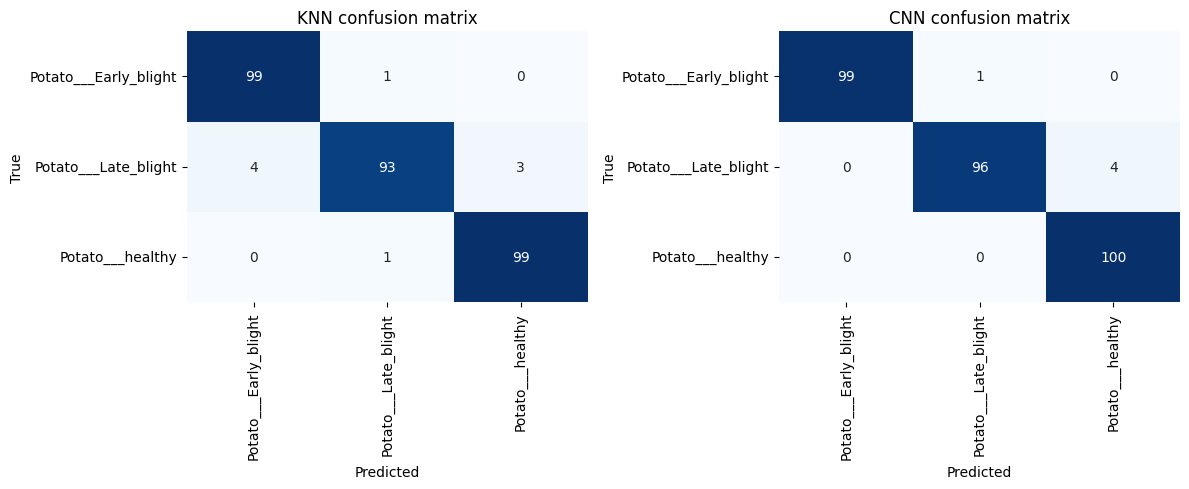

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_confusion_matrices(knn_metrics, cnn_metrics, class_names, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metrics, title in [
        (axes[0], knn_metrics, "KNN"),
        (axes[1], cnn_metrics, "CNN"),
    ]:
        sns.heatmap(
            metrics["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False,
        )
        ax.set_title(f"{title} confusion matrix")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


y_test = np.load("y_test.npy")
class_names = open("class_names.txt").read().splitlines()
y_pred_knn = np.load("y_pred_knn_test.npy")
y_pred_cnn = np.load("y_pred_cnn_test.npy")

knn_metrics = evaluate_predictions(y_test, y_pred_knn, class_names)
cnn_metrics = evaluate_predictions(y_test, y_pred_cnn, class_names)
compare_models(knn_metrics, cnn_metrics, class_names)

plot_confusion_matrices(knn_metrics, cnn_metrics, class_names, save_path="knn_confusion_matrix.png")


## Final: restart the API with the trained checkpoint

No ngrok - once this passes, deploy `app.py` + `model.py` + `labels.py` + `knowledge.py` + `models/` (this repo's `backend/` folder) straight to a Hugging Face Space for a permanent public URL.

In [36]:
get_ipython().system_raw('pkill -9 -f "uvicorn app:app"')
import time; time.sleep(2)
get_ipython().system_raw('nohup uvicorn app:app --host 0.0.0.0 --port 8000 > /content/server.log 2>&1 &')
time.sleep(5)
!curl -s http://localhost:8000/health
